In [9]:
!pip install pandas numpy matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [69]:
# Load each CSV as a separate run
from glob import glob

def load_runs(platform):
    """Load all CSVs for a platform as separate dataframes (runs)"""
    test_dir = Path('test_measurements') / platform
    csvs = sorted(glob(str(test_dir / 'test_*' / '*.csv')))
    runs = [pd.read_csv(csv) for csv in csvs]
    return runs

docker_runs = load_runs('docker')
podman_runs = load_runs('podman')

print(f'Docker: {len(docker_runs)} runs')
print(f'Podman: {len(podman_runs)} runs')

Docker: 5 runs
Podman: 5 runs


In [70]:
# Normalize time and average CPU usage across runs
def average_runs(runs):
    """Normalize time for each run, interpolate to common time axis, and average"""
    # Normalize time to start at 0 for each run (convert to seconds)
    normalized_runs = []
    for df in runs:
        df_norm = df.copy()
        df_norm['time'] = (df_norm['Time'] - df_norm['Time'].min()) / 1000
        normalized_runs.append(df_norm)
    
    # Create common time axis
    max_time = max(df['time'].max() for df in normalized_runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Get CPU columns
    cpu_cols = [col for col in runs[0].columns if col.startswith('CPU_USAGE_')]
    
    # Interpolate and average
    all_cpu_data = []
    for df_norm in normalized_runs:
        cpu_mean = df_norm[cpu_cols].mean(axis=1)  # Average across CPUs
        cpu_interp = np.interp(time_axis, df_norm['time'], cpu_mean)
        all_cpu_data.append(cpu_interp)
    
    all_cpu_data = np.array(all_cpu_data)
    mean = all_cpu_data.mean(axis=0)
    std = all_cpu_data.std(axis=0)
    
    return time_axis, mean, std

docker_time, docker_mean, docker_std = average_runs(docker_runs)
podman_time, podman_mean, podman_std = average_runs(podman_runs)

print('Averaged runs ready')

Averaged runs ready


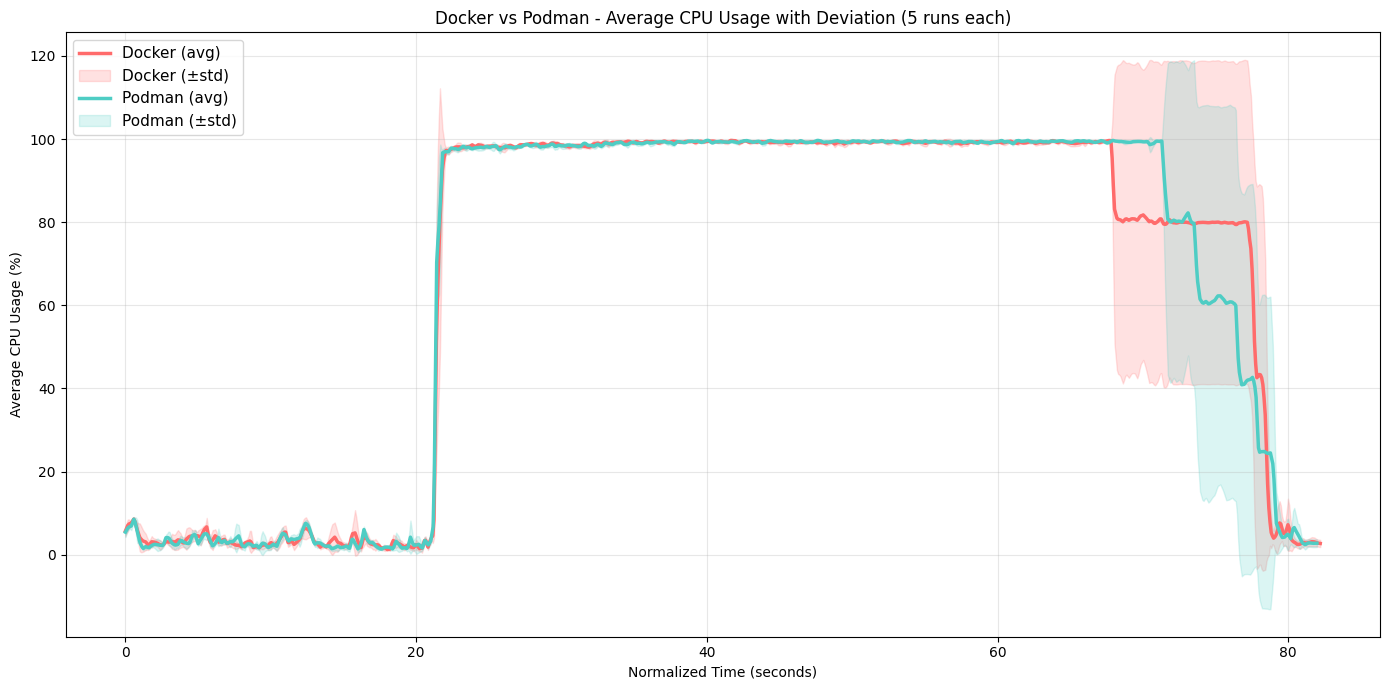

In [71]:
# Plot Docker vs Podman - averaged CPU usage with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_time, docker_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_time,
                  docker_mean - docker_std,
                  docker_mean + docker_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_time, podman_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_time,
                  podman_mean - podman_std,
                  podman_mean + podman_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Average CPU Usage (%)')
plt.title('Docker vs Podman - Average CPU Usage with Deviation (5 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# Calculate cumulative energy for each run
def calculate_energy(runs):
    """Calculate cumulative energy for each run using energy deltas"""
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)', 'PACKAGE_ENERGY (J)']
    
    energy_runs = []
    for df in runs:
        df_energy = df.copy()
        # Normalize time to start at 0 (in seconds)
        df_energy['time'] = (df_energy['Time'] - df_energy['Time'].min()) / 1000
        
        # Calculate total energy by summing available energy columns
        available_cols = [col for col in energy_columns if col in df_energy.columns]
        
        if available_cols:
            # Sum energy deltas (difference from first measurement)
            df_energy['cumulative_energy'] = df_energy[available_cols].sum(axis=1) - df_energy[available_cols].iloc[0].sum()
        else:
            raise ValueError(f'No energy columns found. Available: {df_energy.columns.tolist()}')
        
        energy_runs.append(df_energy)
    
    return energy_runs

docker_energy_runs = calculate_energy(docker_runs)
podman_energy_runs = calculate_energy(podman_runs)

print('Energy calculated for all runs')

Energy calculated for all runs


In [63]:
# Normalize and average energy across runs
def average_energy_runs(runs):
    """Average cumulative energy across runs"""
    # Create common time axis
    max_time = max(df['time'].max() for df in runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Interpolate energy for each run
    all_energy_data = []
    for df in runs:
        energy_interp = np.interp(time_axis, df['time'], df['cumulative_energy'])
        all_energy_data.append(energy_interp)
    
    all_energy_data = np.array(all_energy_data)
    mean = all_energy_data.mean(axis=0)
    std = all_energy_data.std(axis=0)
    
    return time_axis, mean, std

docker_energy_time, docker_energy_mean, docker_energy_std = average_energy_runs(docker_energy_runs)
podman_energy_time, podman_energy_mean, podman_energy_std = average_energy_runs(podman_energy_runs)

print('Energy averaged across runs')

Energy averaged across runs


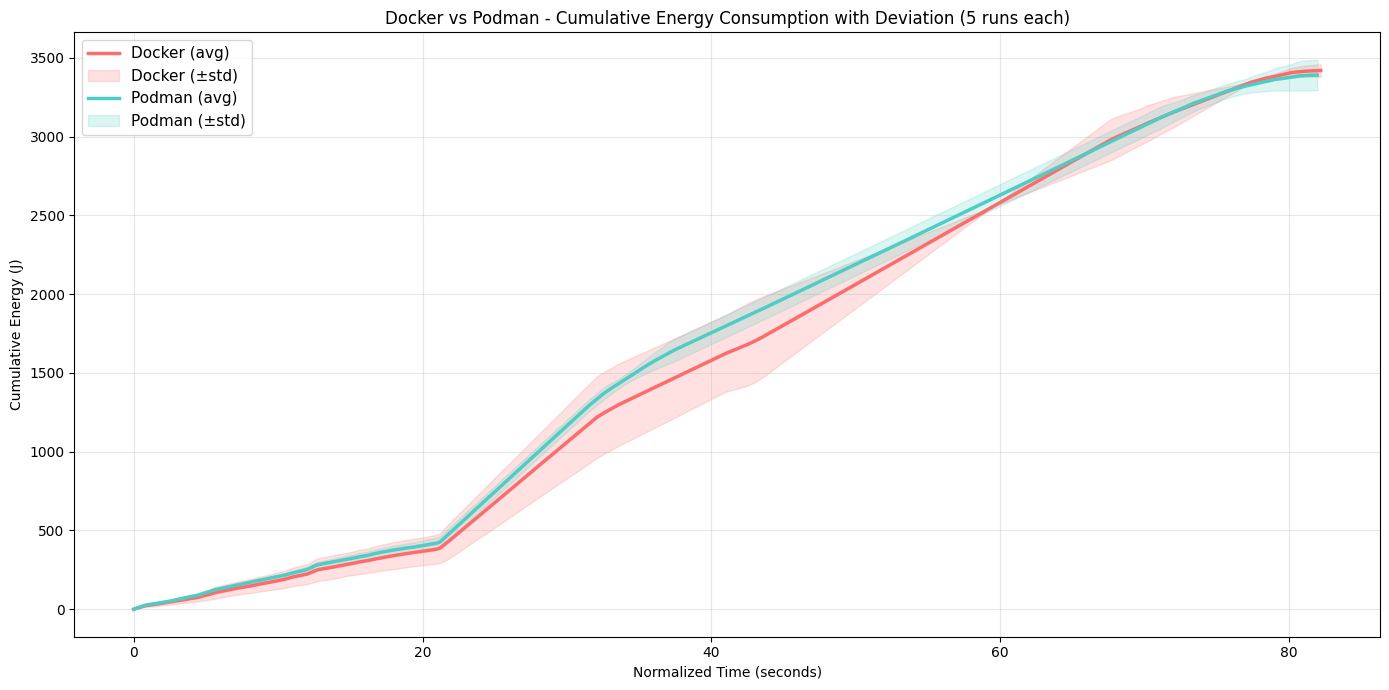

In [68]:
# Plot Docker vs Podman - averaged energy consumption with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_energy_time, docker_energy_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_energy_time,
                  docker_energy_mean - docker_energy_std,
                  docker_energy_mean + docker_energy_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_energy_time, podman_energy_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_energy_time,
                  podman_energy_mean - podman_energy_std,
                  podman_energy_mean + podman_energy_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Cumulative Energy (J)')
plt.title('Docker vs Podman - Cumulative Energy Consumption with Deviation (5 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()